<a href="https://colab.research.google.com/github/mogab12/Sistemas-Inteligentes/blob/main/ex_aula_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Para abrir o notebook no Google Colab, altere o domínio `github.com` para `githubtocolab.com`

<div class="alert alert-block alert-danger">
Para praticar programação, é importante que você erre, leia as mensagens de erro e tente corrigí-los.
    
Dessa forma, no Google Colab, é importante que você DESATIVE OS RECURSOS DE AUTOCOMPLETAR:

- Menu Ferramentas -> Configurações
- Na janela que é aberta:
  - Seção Editor -> Desativar "Mostrar sugestões de preenchimento de código com base no contexto"
  - Seção Assistência de IA -> Desabilitar itens

Na versão em inglês:

- Menu Tools -> Settings
- Na janela que é aberta:
  - Seção Editor -> Desativar "Show context-powered code completions"
  - Seção AI Assistance -> Desabilitar itens
</div>

# PSI3471 - Aula de Exercícios 03

# Perceptron de Rosenblatt e Regressão Logística

# Exercício 1

Neste exercício vamos utilizar o neurônio de Rosenblatt para implementar a função lógica AND.

Iniciamos importando as bibliotecas necessárias para implementar o neurônio de Rosenblatt.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

Vamos gerar os dados de treinamento do problema começando pelo AND.

<div class="alert alert-block alert-success">
Complete o código a seguir:
</div>

In [ ]:
Nt = 100  # número de pontos de treinamento

#############
# x deve ser uma matriz com Nt linhas e 2 colunas com valores 0 ou 1 aleatórios,
# que pode ser gerada usando as funções np.round e np.random.uniform.
# d deve ser um vetor coluna com Nt linhas contendo o resultado da função lógica
# AND aplicada ao vetor x. Para isso use a função np.logical_and.
# Note que a função np.logical_and devolve um vetor com elementos do tipo boolean.
# Para transformar os elementos para o tipo inteiro, basta multiplicá-lo por 1
# ou usar o método .astype(int)


x = np.zeros((Nt,2))
x[:,0] = np.round(np.random.uniform(size=Nt))
x[:,1] = np.round(np.random.uniform(size=Nt))
d = 1*np.logical_and(x[:,0], x[:,1])
#############

A função a seguir implementa o neurônio de Rosenblatt no modo mini-batch. Modifique o programa do algoritmo LMS no modo mini- inserindo a função de ativação.
Para obter 0 ou 1 na saída, deve-se usar a função degrau em vez da função sinal. Para isso, use a função `np.heaviside`.
Uma outra modificação que deve ser considerada é a inicialização dos pesos e bias, que agora devem ser inicializados com valores aleatórios uniformemente distribuídos no intervalo [-dw, dw].

<div class="alert alert-block alert-success">
Complete o código a seguir:
</div>

In [ ]:
def Rosenblatt_minibatch(x, d, eta, Nt, Ne, Nb, dw):
    """
    W = Rosenblatt_minibatch(x, d, eta, Nt, Ne, Nb)
    x: sinal de entrada
    d: sinal desejado
    eta: passo de adaptação
    Nt: número de dados de treinamento
    Ne: número de épocas
    Nb: tamanho do mini-batch
    dw: inicialização dos pesos e bias com distribuição uniforme no invervalo [-dw, dw]
    """
    """
    Novamente, vamos juntar o sinal de entrada e o sinal desejado em um único vetor,
    uma vez que a cada época vamos embaralhar os dados.
    Ao fazer isso, já inserimos uma coluna de 1's para levar em conta o bias.
    """
    M = x.shape[1]
    Nmb = int(np.floor(Nt / Nb))
    W = (np.random.rand(Ne * Nmb + 1, M + 1)*2 - np.ones((Ne * Nmb + 1, M + 1)))*dw
    d = d.reshape(-1, 1)
    Xd = np.hstack((np.ones((Nt, 1)), x, d))

    eta = eta / Nb

    for k in range(Ne):
        np.random.shuffle(Xd)
        x = Xd[:, 0 : M + 1]
        d = Xd[:, [M + 1]]

        for l in range(Nmb):
            start = l * Nb
            end = start + Nb

            xmb = x[start:end, :]
            dmb = d[start:end, :]

            m = k * Nmb + l

            emb = dmb - np.heaviside(xmb @ W[m, :].reshape(-1, 1),0)

            W[m + 1, :] = W[m, :] + eta * np.sum(xmb * emb, axis=0)

    return W

In [ ]:
eta = 0.5  # passo de adaptação do algoritmo de Rosenblatt
Nb = 20
Ne = 100
dw = 2

W = Rosenblatt_minibatch(x, d, eta, Nt, Ne, Nb, dw)

# Wfinal deve ser os valores de pesos e bias da última iteração
Wfinal = W[-1]
print(Wfinal)

[-0.35241828  0.15501589  0.34386528]


<div class="alert alert-block alert-success">
Complete o código a seguir:
</div>

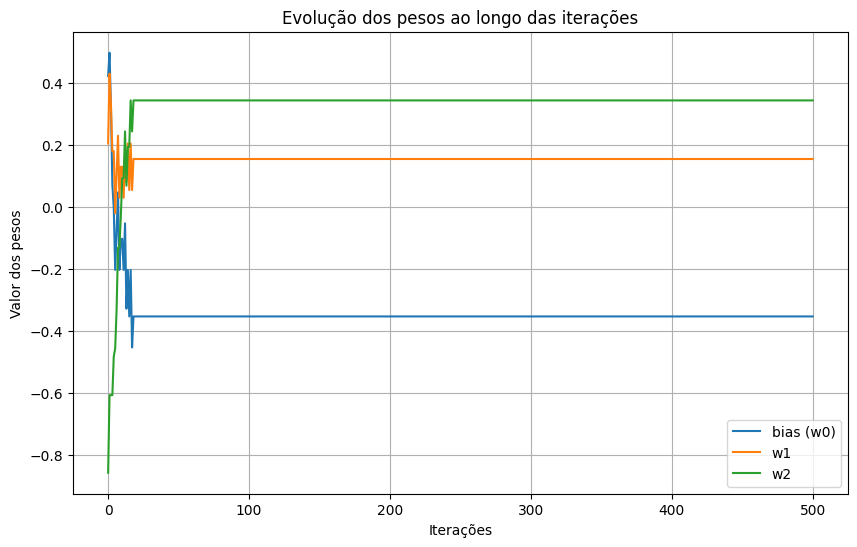

In [ ]:
import matplotlib.pyplot as plt

# número de iterações
iters = np.arange(W.shape[0])

plt.figure(figsize=(10,6))

# bias (primeira coluna)
plt.plot(iters, W[:, 0], label='bias (w0)')

# demais pesos
for i in range(1, W.shape[1]):
    plt.plot(iters, W[:, i], label=f'w{i}')

plt.xlabel('Iterações')
plt.ylabel('Valor dos pesos')
plt.title('Evolução dos pesos ao longo das iterações')
plt.legend()
plt.grid(True)

plt.show()

<div class="alert alert-block alert-success">
Complete o código a seguir:
</div>

In [ ]:
# Gere os dados de teste, calcule a taxa de erro e gere a reta de separação das
# regiões, mostrando em um mesmo gráfico a reta e os dados de teste classificados.
# Comente o resultado, explicando se é possível utilizar o neurônio de Rosenblatt
# para implementar esta função lógica.
Nt_test = 50
x_test = np.zeros((Nt_test, 2))
x_test[:,0] = np.round(np.random.uniform(size=Nt_test))
x_test[:,1] = np.round(np.random.uniform(size=Nt_test))
d_test = 1*np.logical_and(x_test[:,0], x_test[:,1])
W_final = W[-1, :]
y_test = np.heaviside(x_test @ W_final[1:] + W_final[0], 1)
error_rate = np.mean(y_test != d_test) * 100
print(f"Taxa de erro: {error_rate:.2f}%")

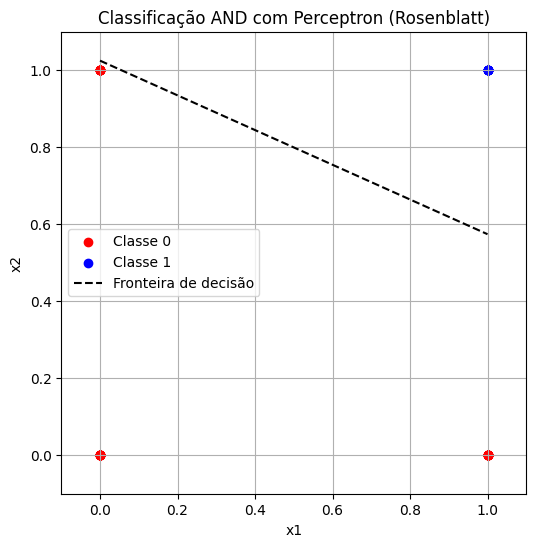

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6,6))

# pontos classificados
plt.scatter(x_test[d_test==0,0], x_test[d_test==0,1], color='red', label='Classe 0')
plt.scatter(x_test[d_test==1,0], x_test[d_test==1,1], color='blue', label='Classe 1')

# reta de separação
x_vals = np.array([0,1])
y_vals = -(W_final[1]/W_final[2])*x_vals - (W_final[0]/W_final[2])
plt.plot(x_vals, y_vals, 'k--', label='Fronteira de decisão')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Classificação AND com Perceptron (Rosenblatt)')
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)
plt.legend()
plt.grid(True)
plt.show()

# Exercício 2

Repita o exercício anterior considerando as portas lógicas OR e o XOR.

## Resolução

### OR

In [ ]:
Nt = 100


x = np.zeros((Nt,2))
x[:,0] = np.round(np.random.uniform(size=Nt))
x[:,1] = np.round(np.random.uniform(size=Nt))
d = 1*np.logical_or(x[:,0], x[:,1])

In [ ]:
eta = 0.5  # passo de adaptação do algoritmo de Rosenblatt
Nb = 20
Ne = 100
dw = 2

W = Rosenblatt_minibatch(x, d, eta, Nt, Ne, Nb, dw)

# Wfinal deve ser os valores de pesos e bias da última iteração
Wfinal = W[-1]
print(Wfinal)

[-0.07688616  1.76445954  0.12356815]


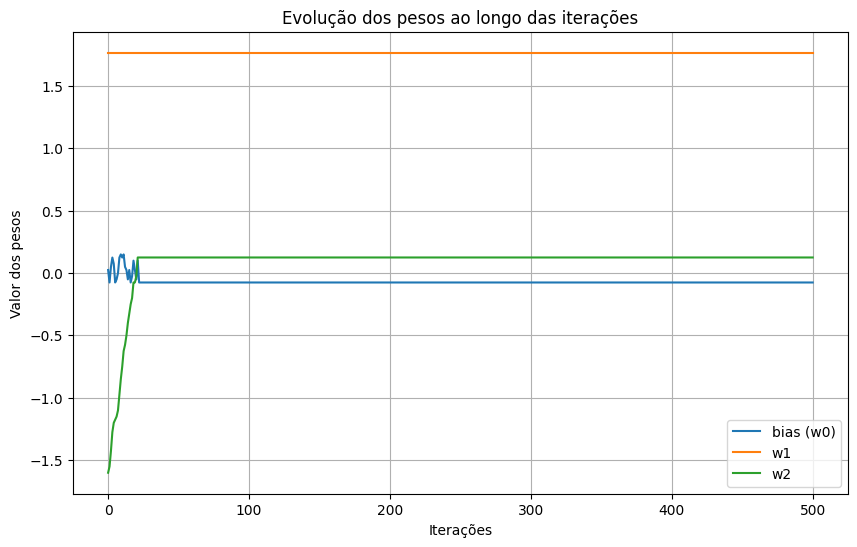

In [ ]:
import matplotlib.pyplot as plt

# número de iterações
iters = np.arange(W.shape[0])

plt.figure(figsize=(10,6))

# bias (primeira coluna)
plt.plot(iters, W[:, 0], label='bias (w0)')

# demais pesos
for i in range(1, W.shape[1]):
    plt.plot(iters, W[:, i], label=f'w{i}')

plt.xlabel('Iterações')
plt.ylabel('Valor dos pesos')
plt.title('Evolução dos pesos ao longo das iterações')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Gere os dados de teste, calcule a taxa de erro e gere a reta de separação das
# regiões, mostrando em um mesmo gráfico a reta e os dados de teste classificados.
# Comente o resultado, explicando se é possível utilizar o neurônio de Rosenblatt
# para implementar esta função lógica.
Nt_test = 50
x_test = np.zeros((Nt_test, 2))
x_test[:,0] = np.round(np.random.uniform(size=Nt_test))
x_test[:,1] = np.round(np.random.uniform(size=Nt_test))
d_test = 1*np.logical_or(x_test[:,0], x_test[:,1])
W_final = W[-1, :]
y_test = np.heaviside(x_test @ W_final[1:] + W_final[0], 1)
error_rate = np.mean(y_test != d_test) * 100
print(f"Taxa de erro: {error_rate:.2f}%")

Taxa de erro: 0.00%


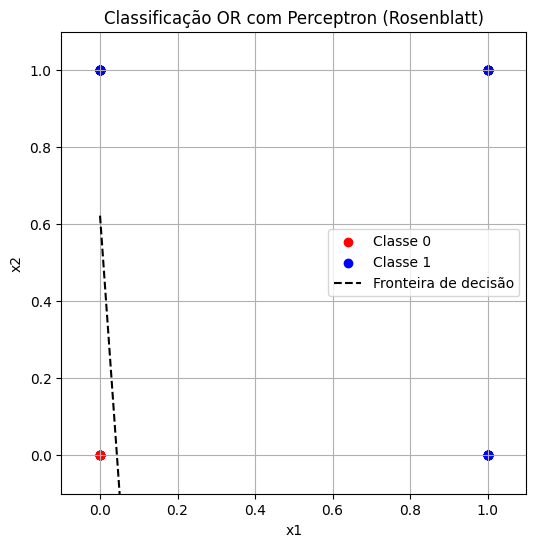

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6,6))

# pontos classificados
plt.scatter(x_test[d_test==0,0], x_test[d_test==0,1], color='red', label='Classe 0')
plt.scatter(x_test[d_test==1,0], x_test[d_test==1,1], color='blue', label='Classe 1')

# reta de separação
x_vals = np.array([0,1])
y_vals = -(W_final[1]/W_final[2])*x_vals - (W_final[0]/W_final[2])
plt.plot(x_vals, y_vals, 'k--', label='Fronteira de decisão')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Classificação OR com Perceptron (Rosenblatt)')
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)
plt.legend()
plt.grid(True)
plt.show()

### XOR

In [ ]:
Nt = 100


x = np.zeros((Nt,2))
x[:,0] = np.round(np.random.uniform(size=Nt))
x[:,1] = np.round(np.random.uniform(size=Nt))
d = 1*np.logical_xor(x[:,0], x[:,1])

In [ ]:
eta = 0.5  # passo de adaptação do algoritmo de Rosenblatt
Nb = 20
Ne = 100
dw = 2

W = Rosenblatt_minibatch(x, d, eta, Nt, Ne, Nb, dw)

# Wfinal deve ser os valores de pesos e bias da última iteração
Wfinal = W[-1]
print(Wfinal)

[-0.13511381  0.07428279  0.09656835]


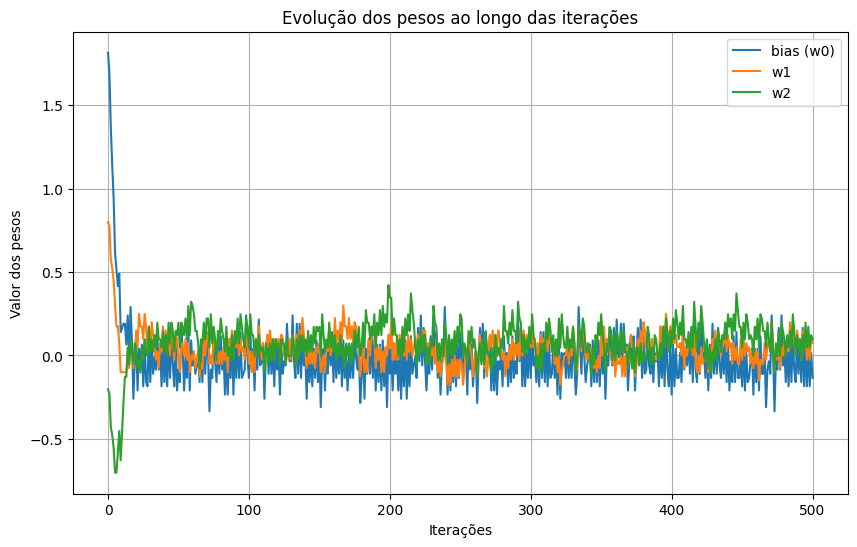

In [ ]:
import matplotlib.pyplot as plt

# número de iterações
iters = np.arange(W.shape[0])

plt.figure(figsize=(10,6))

# bias (primeira coluna)
plt.plot(iters, W[:, 0], label='bias (w0)')

# demais pesos
for i in range(1, W.shape[1]):
    plt.plot(iters, W[:, i], label=f'w{i}')

plt.xlabel('Iterações')
plt.ylabel('Valor dos pesos')
plt.title('Evolução dos pesos ao longo das iterações')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Gere os dados de teste, calcule a taxa de erro e gere a reta de separação das
# regiões, mostrando em um mesmo gráfico a reta e os dados de teste classificados.
# Comente o resultado, explicando se é possível utilizar o neurônio de Rosenblatt
# para implementar esta função lógica.
Nt_test = 50
x_test = np.zeros((Nt_test, 2))
x_test[:,0] = np.round(np.random.uniform(size=Nt_test))
x_test[:,1] = np.round(np.random.uniform(size=Nt_test))
d_test = 1*np.logical_xor(x_test[:,0], x_test[:,1])
W_final = W[-1, :]
y_test = np.heaviside(x_test @ W_final[1:] + W_final[0], 1)
error_rate = np.mean(y_test != d_test) * 100
print(f"Taxa de erro: {error_rate:.2f}%")

Taxa de erro: 72.00%


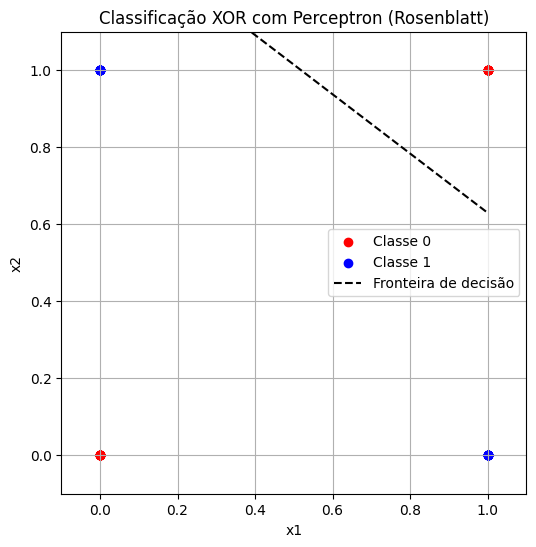

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6,6))

# pontos classificados
plt.scatter(x_test[d_test==0,0], x_test[d_test==0,1], color='red', label='Classe 0')
plt.scatter(x_test[d_test==1,0], x_test[d_test==1,1], color='blue', label='Classe 1')

# reta de separação
x_vals = np.array([0,1])
y_vals = -(W_final[1]/W_final[2])*x_vals - (W_final[0]/W_final[2])
plt.plot(x_vals, y_vals, 'k--', label='Fronteira de decisão')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Classificação XOR com Perceptron (Rosenblatt)')
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)
plt.legend()
plt.grid(True)
plt.show()

# Exercício 3

Repita o exercício para as portas lógicas AND, OR e XOR considerando a otimização do modelo utilizando a regressão logística com as seguintes funções custo:
- Erro quadrático médio
- Entropia cruzada

## Resolução

In [ ]:
def sigmoid(x):
  return 1/(1+np.exp(-x))

In [ ]:
def Rosenblatt_minibatch_MSE(x, d, eta, Nt, Ne, Nb, dw):
    """
    W = Rosenblatt_minibatch(x, d, eta, Nt, Ne, Nb)
    x: sinal de entrada
    d: sinal desejado
    eta: passo de adaptação
    Nt: número de dados de treinamento
    Ne: número de épocas
    Nb: tamanho do mini-batch
    dw: inicialização dos pesos e bias com distribuição uniforme no invervalo [-dw, dw]
    """
    """
    Novamente, vamos juntar o sinal de entrada e o sinal desejado em um único vetor,
    uma vez que a cada época vamos embaralhar os dados.
    Ao fazer isso, já inserimos uma coluna de 1's para levar em conta o bias.
    """
    M = x.shape[1]
    Nmb = int(np.floor(Nt / Nb))
    W = (np.random.rand(Ne * Nmb + 1, M + 1)*2 - np.ones((Ne * Nmb + 1, M + 1)))*dw
    d = d.reshape(-1, 1)
    Xd = np.hstack((np.ones((Nt, 1)), x, d))

    eta = eta / Nb

    for k in range(Ne):
        np.random.shuffle(Xd)
        x = Xd[:, 0 : M + 1]
        d = Xd[:, [M + 1]]

        for l in range(Nmb):
            start = l * Nb
            end = start + Nb

            xmb = x[start:end, :]
            dmb = d[start:end, :]

            m = k * Nmb + l
            y_hat = sigmoid(xmb @ W[m, :].reshape(-1, 1))
            error = dmb - y_hat
            grad = -2 * (xmb.T @ (error * y_hat * (1 - y_hat)))
            W[m + 1, :] = W[m, :] - eta * grad.flatten()

    return W

In [ ]:
def Rosenblatt_minibatch_EC(x, d, eta, Nt, Ne, Nb, dw):
    """
    W = Rosenblatt_minibatch(x, d, eta, Nt, Ne, Nb)
    x: sinal de entrada
    d: sinal desejado
    eta: passo de adaptação
    Nt: número de dados de treinamento
    Ne: número de épocas
    Nb: tamanho do mini-batch
    dw: inicialização dos pesos e bias com distribuição uniforme no invervalo [-dw, dw]
    """
    """
    Novamente, vamos juntar o sinal de entrada e o sinal desejado em um único vetor,
    uma vez que a cada época vamos embaralhar os dados.
    Ao fazer isso, já inserimos uma coluna de 1's para levar em conta o bias.
    """
    M = x.shape[1]
    Nmb = int(np.floor(Nt / Nb))
    W = (np.random.rand(Ne * Nmb + 1, M + 1)*2 - np.ones((Ne * Nmb + 1, M + 1)))*dw
    d = d.reshape(-1, 1)
    Xd = np.hstack((np.ones((Nt, 1)), x, d))

    eta = eta / Nb

    for k in range(Ne):
        np.random.shuffle(Xd)
        x = Xd[:, 0 : M + 1]
        d = Xd[:, [M + 1]]

        for l in range(Nmb):
            start = l * Nb
            end = start + Nb

            xmb = x[start:end, :]
            dmb = d[start:end, :]

            m = k * Nmb + l
            y_hat = sigmoid(xmb @ W[m, :].reshape(-1, 1))
            error = dmb - y_hat
            grad = - (xmb.T @ error)
            W[m + 1, :] = W[m, :] - eta * grad.flatten()

    return W

In [ ]:
Nt = 100  # número de pontos de treinamento

x = np.zeros((Nt,2))
x[:,0] = np.round(np.random.uniform(size=Nt))
x[:,1] = np.round(np.random.uniform(size=Nt))
d = 1*np.logical_and(x[:,0], x[:,1])

In [ ]:
eta = 1  # passo de adaptação do algoritmo de Rosenblatt
Nb = 20
Ne = 500
dw = 2

W = Rosenblatt_minibatch_EC(x, d, eta, Nt, Ne, Nb, dw)

# Wfinal deve ser os valores de pesos e bias da última iteração
Wfinal = W[-1]
print(Wfinal)

[-14.16181441   9.10536034   9.48368198]


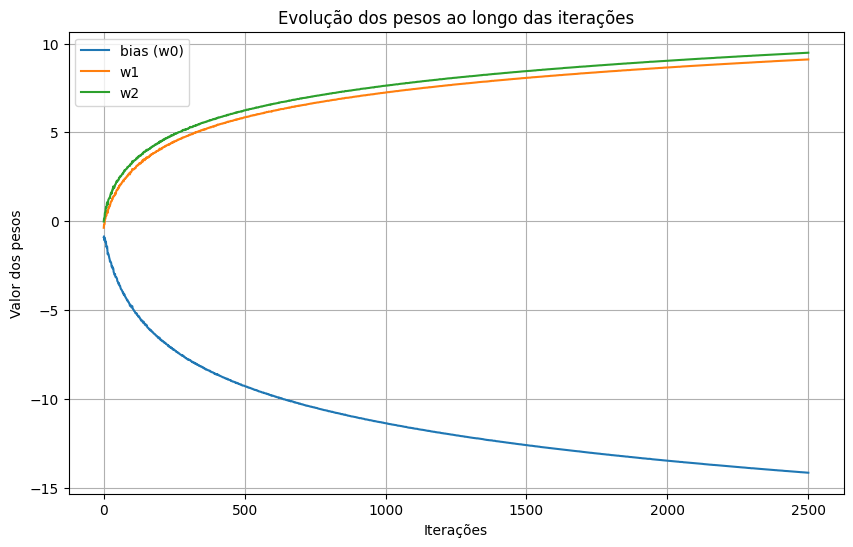

In [ ]:
import matplotlib.pyplot as plt

# número de iterações
iters = np.arange(W.shape[0])

plt.figure(figsize=(10,6))

# bias (primeira coluna)
plt.plot(iters, W[:, 0], label='bias (w0)')

# demais pesos
for i in range(1, W.shape[1]):
    plt.plot(iters, W[:, i], label=f'w{i}')

plt.xlabel('Iterações')
plt.ylabel('Valor dos pesos')
plt.title('Evolução dos pesos ao longo das iterações')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Gere os dados de teste, calcule a taxa de erro e gere a reta de separação das
# regiões, mostrando em um mesmo gráfico a reta e os dados de teste classificados.
# Comente o resultado, explicando se é possível utilizar o neurônio de Rosenblatt
# para implementar esta função lógica.
Nt_test = 50
x_test = np.zeros((Nt_test, 2))
x_test[:,0] = np.round(np.random.uniform(size=Nt_test))
x_test[:,1] = np.round(np.random.uniform(size=Nt_test))
d_test = 1*np.logical_and(x_test[:,0], x_test[:,1])
W_final = W[-1, :]
y_test = np.heaviside(x_test @ W_final[1:] + W_final[0], 1)
error_rate = np.mean(y_test != d_test) * 100
print(f"Taxa de erro: {error_rate:.2f}%")

Taxa de erro: 0.00%


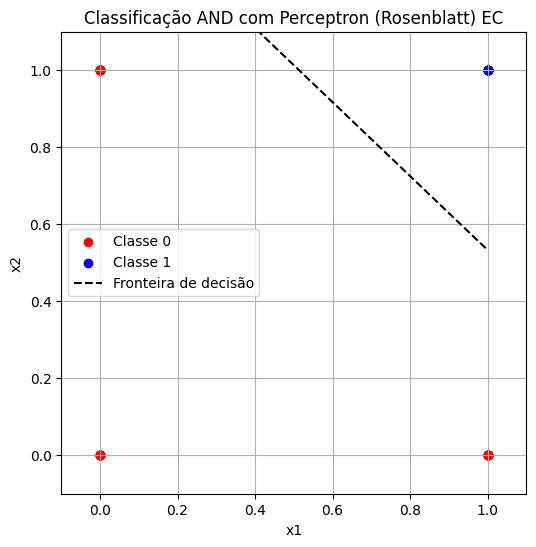

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6,6))

# pontos classificados
plt.scatter(x_test[d_test==0,0], x_test[d_test==0,1], color='red', label='Classe 0')
plt.scatter(x_test[d_test==1,0], x_test[d_test==1,1], color='blue', label='Classe 1')

# reta de separação
x_vals = np.array([0,1])
y_vals = -(W_final[1]/W_final[2])*x_vals - (W_final[0]/W_final[2])
plt.plot(x_vals, y_vals, 'k--', label='Fronteira de decisão')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Classificação AND com Perceptron (Rosenblatt) EC')
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
Nt = 100  # número de pontos de treinamento

x = np.zeros((Nt,2))
x[:,0] = np.round(np.random.uniform(size=Nt))
x[:,1] = np.round(np.random.uniform(size=Nt))
d = 1*np.logical_and(x[:,0], x[:,1])

In [ ]:
eta = 1  # passo de adaptação do algoritmo de Rosenblatt
Nb = 20
Ne = 500
dw = 2

W = Rosenblatt_minibatch_MSE(x, d, eta, Nt, Ne, Nb, dw)

# Wfinal deve ser os valores de pesos e bias da última iteração
Wfinal = W[-1]
print(Wfinal)

[-8.75065203  5.69354637  5.76834456]


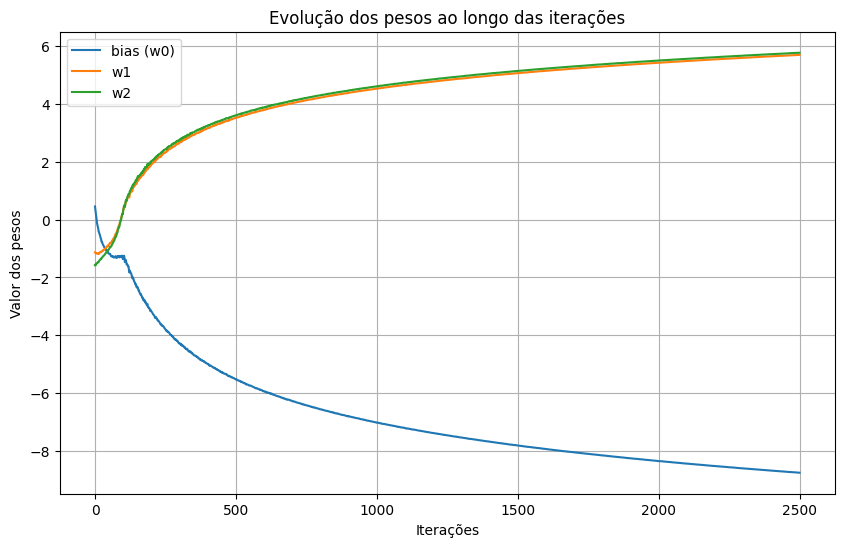

In [ ]:
import matplotlib.pyplot as plt

# número de iterações
iters = np.arange(W.shape[0])

plt.figure(figsize=(10,6))

# bias (primeira coluna)
plt.plot(iters, W[:, 0], label='bias (w0)')

# demais pesos
for i in range(1, W.shape[1]):
    plt.plot(iters, W[:, i], label=f'w{i}')

plt.xlabel('Iterações')
plt.ylabel('Valor dos pesos')
plt.title('Evolução dos pesos ao longo das iterações')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Gere os dados de teste, calcule a taxa de erro e gere a reta de separação das
# regiões, mostrando em um mesmo gráfico a reta e os dados de teste classificados.
# Comente o resultado, explicando se é possível utilizar o neurônio de Rosenblatt
# para implementar esta função lógica.
Nt_test = 50
x_test = np.zeros((Nt_test, 2))
x_test[:,0] = np.round(np.random.uniform(size=Nt_test))
x_test[:,1] = np.round(np.random.uniform(size=Nt_test))
d_test = 1*np.logical_and(x_test[:,0], x_test[:,1])
W_final = W[-1, :]
y_test = np.heaviside(x_test @ W_final[1:] + W_final[0], 1)
error_rate = np.mean(y_test != d_test) * 100
print(f"Taxa de erro: {error_rate:.2f}%")

Taxa de erro: 0.00%


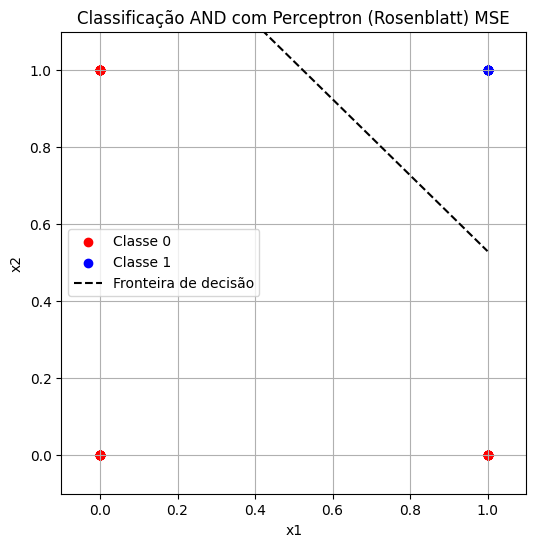

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6,6))

# pontos classificados
plt.scatter(x_test[d_test==0,0], x_test[d_test==0,1], color='red', label='Classe 0')
plt.scatter(x_test[d_test==1,0], x_test[d_test==1,1], color='blue', label='Classe 1')

# reta de separação
x_vals = np.array([0,1])
y_vals = -(W_final[1]/W_final[2])*x_vals - (W_final[0]/W_final[2])
plt.plot(x_vals, y_vals, 'k--', label='Fronteira de decisão')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Classificação AND com Perceptron (Rosenblatt) MSE')
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)
plt.legend()
plt.grid(True)
plt.show()

### OR

In [ ]:
Nt = 100  # número de pontos de treinamento

x = np.zeros((Nt,2))
x[:,0] = np.round(np.random.uniform(size=Nt))
x[:,1] = np.round(np.random.uniform(size=Nt))
d = 1*np.logical_or(x[:,0], x[:,1])

In [ ]:
eta = 1  # passo de adaptação do algoritmo de Rosenblatt
Nb = 20
Ne = 500
dw = 2

W = Rosenblatt_minibatch_EC(x, d, eta, Nt, Ne, Nb, dw)

# Wfinal deve ser os valores de pesos e bias da última iteração
Wfinal = W[-1]
print(Wfinal)

[-4.88167907 10.64677256 10.72133972]


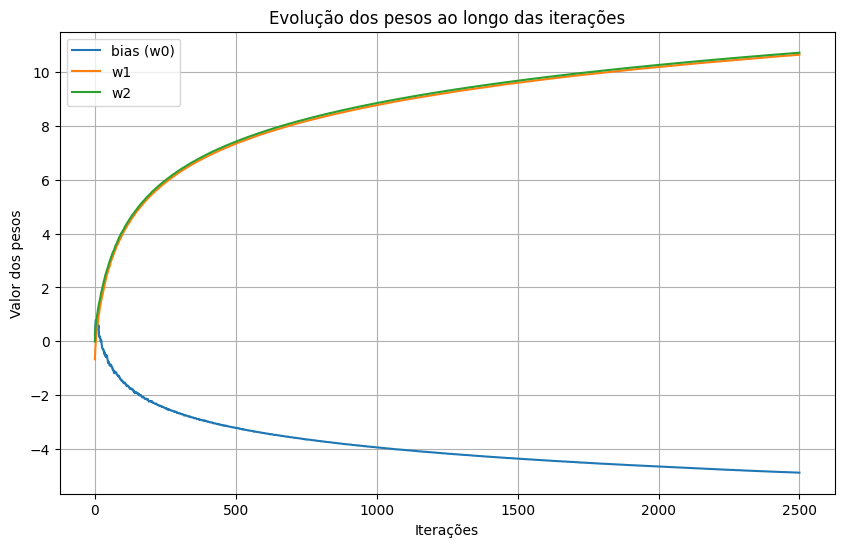

In [ ]:
import matplotlib.pyplot as plt

# número de iterações
iters = np.arange(W.shape[0])

plt.figure(figsize=(10,6))

# bias (primeira coluna)
plt.plot(iters, W[:, 0], label='bias (w0)')

# demais pesos
for i in range(1, W.shape[1]):
    plt.plot(iters, W[:, i], label=f'w{i}')

plt.xlabel('Iterações')
plt.ylabel('Valor dos pesos')
plt.title('Evolução dos pesos ao longo das iterações')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Gere os dados de teste, calcule a taxa de erro e gere a reta de separação das
# regiões, mostrando em um mesmo gráfico a reta e os dados de teste classificados.
# Comente o resultado, explicando se é possível utilizar o neurônio de Rosenblatt
# para implementar esta função lógica.
Nt_test = 50
x_test = np.zeros((Nt_test, 2))
x_test[:,0] = np.round(np.random.uniform(size=Nt_test))
x_test[:,1] = np.round(np.random.uniform(size=Nt_test))
d_test = 1*np.logical_or(x_test[:,0], x_test[:,1])
W_final = W[-1, :]
y_test = np.heaviside(x_test @ W_final[1:] + W_final[0], 1)
error_rate = np.mean(y_test != d_test) * 100
print(f"Taxa de erro: {error_rate:.2f}%")

Taxa de erro: 0.00%


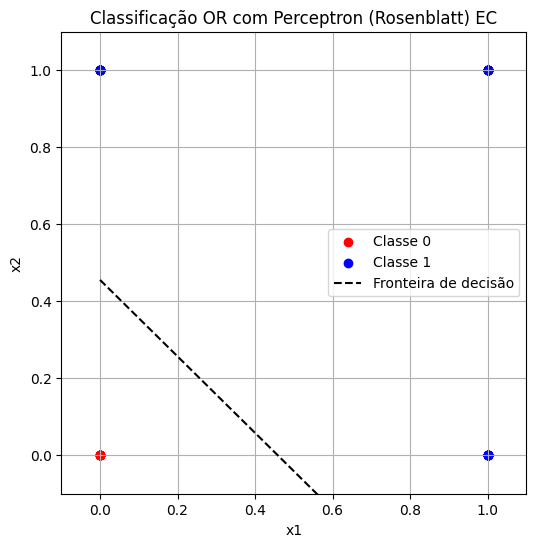

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6,6))

# pontos classificados
plt.scatter(x_test[d_test==0,0], x_test[d_test==0,1], color='red', label='Classe 0')
plt.scatter(x_test[d_test==1,0], x_test[d_test==1,1], color='blue', label='Classe 1')

# reta de separação
x_vals = np.array([0,1])
y_vals = -(W_final[1]/W_final[2])*x_vals - (W_final[0]/W_final[2])
plt.plot(x_vals, y_vals, 'k--', label='Fronteira de decisão')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Classificação OR com Perceptron (Rosenblatt) EC')
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
Nt = 100  # número de pontos de treinamento

x = np.zeros((Nt,2))
x[:,0] = np.round(np.random.uniform(size=Nt))
x[:,1] = np.round(np.random.uniform(size=Nt))
d = 1*np.logical_or(x[:,0], x[:,1])

In [ ]:
eta = 1  # passo de adaptação do algoritmo de Rosenblatt
Nb = 20
Ne = 500
dw = 2

W = Rosenblatt_minibatch_MSE(x, d, eta, Nt, Ne, Nb, dw)

# Wfinal deve ser os valores de pesos e bias da última iteração
Wfinal = W[-1]
print(Wfinal)

[-3.06364517  6.49097658  6.51381158]


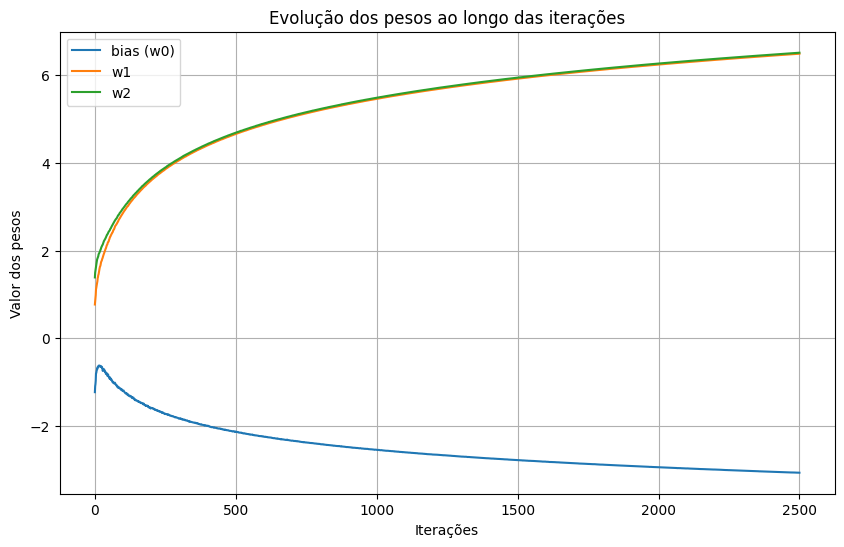

In [ ]:
import matplotlib.pyplot as plt

# número de iterações
iters = np.arange(W.shape[0])

plt.figure(figsize=(10,6))

# bias (primeira coluna)
plt.plot(iters, W[:, 0], label='bias (w0)')

# demais pesos
for i in range(1, W.shape[1]):
    plt.plot(iters, W[:, i], label=f'w{i}')

plt.xlabel('Iterações')
plt.ylabel('Valor dos pesos')
plt.title('Evolução dos pesos ao longo das iterações')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Gere os dados de teste, calcule a taxa de erro e gere a reta de separação das
# regiões, mostrando em um mesmo gráfico a reta e os dados de teste classificados.
# Comente o resultado, explicando se é possível utilizar o neurônio de Rosenblatt
# para implementar esta função lógica.
Nt_test = 50
x_test = np.zeros((Nt_test, 2))
x_test[:,0] = np.round(np.random.uniform(size=Nt_test))
x_test[:,1] = np.round(np.random.uniform(size=Nt_test))
d_test = 1*np.logical_or(x_test[:,0], x_test[:,1])
W_final = W[-1, :]
y_test = np.heaviside(x_test @ W_final[1:] + W_final[0], 1)
error_rate = np.mean(y_test != d_test) * 100
print(f"Taxa de erro: {error_rate:.2f}%")

Taxa de erro: 0.00%


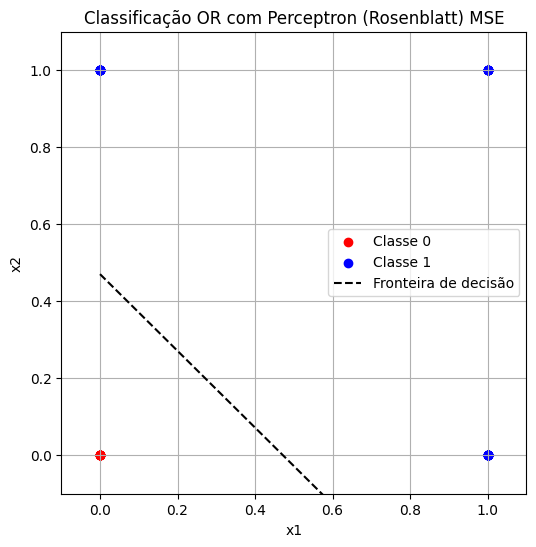

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6,6))

# pontos classificados
plt.scatter(x_test[d_test==0,0], x_test[d_test==0,1], color='red', label='Classe 0')
plt.scatter(x_test[d_test==1,0], x_test[d_test==1,1], color='blue', label='Classe 1')

# reta de separação
x_vals = np.array([0,1])
y_vals = -(W_final[1]/W_final[2])*x_vals - (W_final[0]/W_final[2])
plt.plot(x_vals, y_vals, 'k--', label='Fronteira de decisão')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Classificação OR com Perceptron (Rosenblatt) MSE')
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)
plt.legend()
plt.grid(True)
plt.show()

### XOR

In [ ]:
Nt = 100  # número de pontos de treinamento

x = np.zeros((Nt,2))
x[:,0] = np.round(np.random.uniform(size=Nt))
x[:,1] = np.round(np.random.uniform(size=Nt))
d = 1*np.logical_xor(x[:,0], x[:,1])

In [ ]:
eta = 1  # passo de adaptação do algoritmo de Rosenblatt
Nb = 20
Ne = 500
dw = 2

W = Rosenblatt_minibatch_EC(x, d, eta, Nt, Ne, Nb, dw)

# Wfinal deve ser os valores de pesos e bias da última iteração
Wfinal = W[-1]
print(Wfinal)

[ 0.15932798 -0.29431271  0.2228282 ]


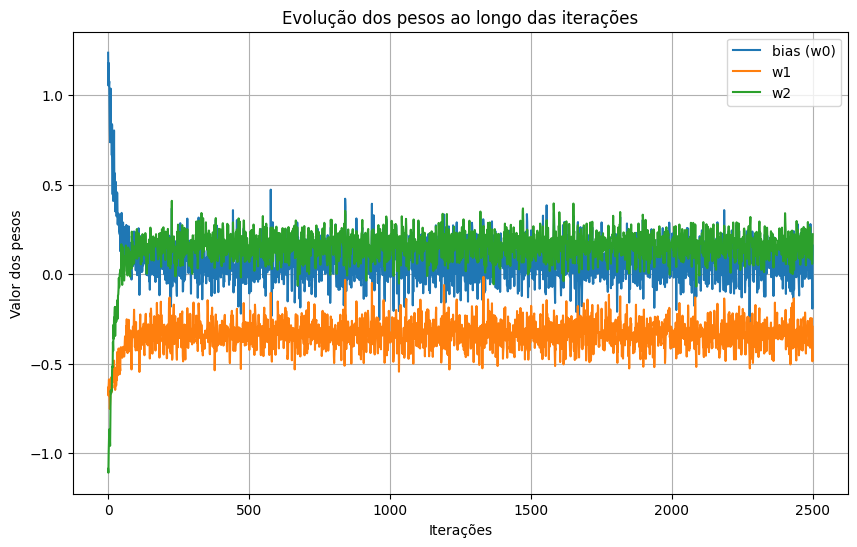

In [ ]:
import matplotlib.pyplot as plt

# número de iterações
iters = np.arange(W.shape[0])

plt.figure(figsize=(10,6))

# bias (primeira coluna)
plt.plot(iters, W[:, 0], label='bias (w0)')

# demais pesos
for i in range(1, W.shape[1]):
    plt.plot(iters, W[:, i], label=f'w{i}')

plt.xlabel('Iterações')
plt.ylabel('Valor dos pesos')
plt.title('Evolução dos pesos ao longo das iterações')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Gere os dados de teste, calcule a taxa de erro e gere a reta de separação das
# regiões, mostrando em um mesmo gráfico a reta e os dados de teste classificados.
# Comente o resultado, explicando se é possível utilizar o neurônio de Rosenblatt
# para implementar esta função lógica.
Nt_test = 50
x_test = np.zeros((Nt_test, 2))
x_test[:,0] = np.round(np.random.uniform(size=Nt_test))
x_test[:,1] = np.round(np.random.uniform(size=Nt_test))
d_test = 1*np.logical_xor(x_test[:,0], x_test[:,1])
W_final = W[-1, :]
y_test = np.heaviside(x_test @ W_final[1:] + W_final[0], 1)
error_rate = np.mean(y_test != d_test) * 100
print(f"Taxa de erro: {error_rate:.2f}%")

Taxa de erro: 82.00%


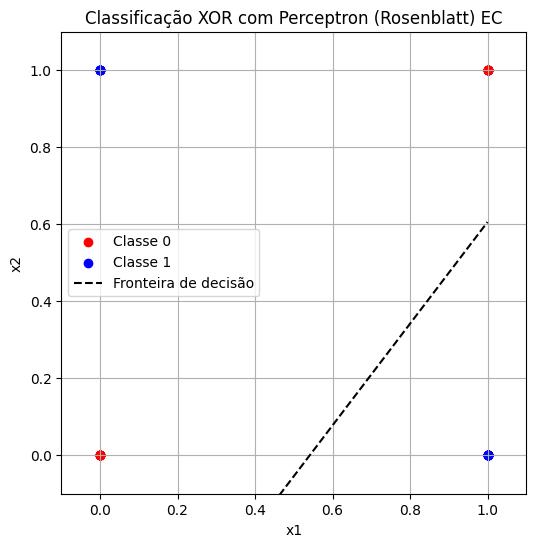

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6,6))

# pontos classificados
plt.scatter(x_test[d_test==0,0], x_test[d_test==0,1], color='red', label='Classe 0')
plt.scatter(x_test[d_test==1,0], x_test[d_test==1,1], color='blue', label='Classe 1')

# reta de separação
x_vals = np.array([0,1])
y_vals = -(W_final[1]/W_final[2])*x_vals - (W_final[0]/W_final[2])
plt.plot(x_vals, y_vals, 'k--', label='Fronteira de decisão')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Classificação XOR com Perceptron (Rosenblatt) EC')
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
Nt = 100  # número de pontos de treinamento

x = np.zeros((Nt,2))
x[:,0] = np.round(np.random.uniform(size=Nt))
x[:,1] = np.round(np.random.uniform(size=Nt))
d = 1*np.logical_xor(x[:,0], x[:,1])

In [ ]:
eta = 1  # passo de adaptação do algoritmo de Rosenblatt
Nb = 20
Ne = 500
dw = 2

W = Rosenblatt_minibatch_MSE(x, d, eta, Nt, Ne, Nb, dw)

# Wfinal deve ser os valores de pesos e bias da última iteração
Wfinal = W[-1]
print(Wfinal)

[-2.97717854 -6.34059613  5.89657385]


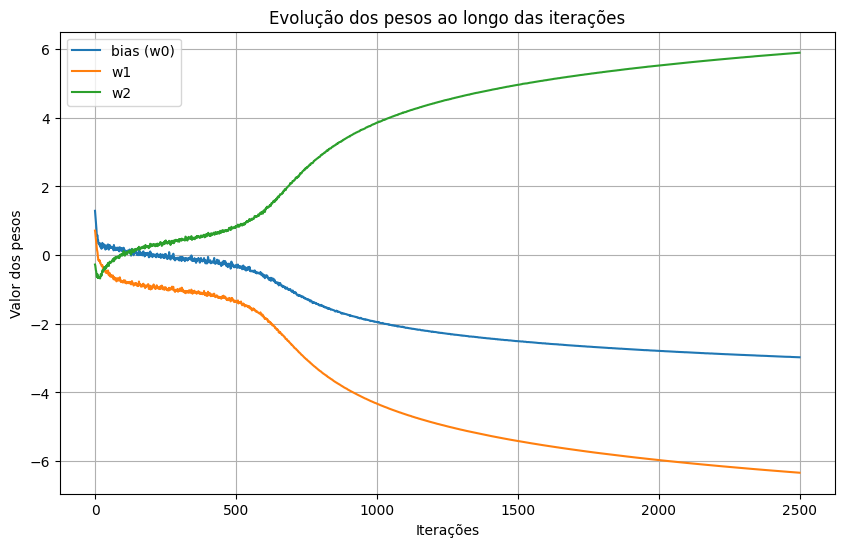

In [ ]:
import matplotlib.pyplot as plt

# número de iterações
iters = np.arange(W.shape[0])

plt.figure(figsize=(10,6))

# bias (primeira coluna)
plt.plot(iters, W[:, 0], label='bias (w0)')

# demais pesos
for i in range(1, W.shape[1]):
    plt.plot(iters, W[:, i], label=f'w{i}')

plt.xlabel('Iterações')
plt.ylabel('Valor dos pesos')
plt.title('Evolução dos pesos ao longo das iterações')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Gere os dados de teste, calcule a taxa de erro e gere a reta de separação das
# regiões, mostrando em um mesmo gráfico a reta e os dados de teste classificados.
# Comente o resultado, explicando se é possível utilizar o neurônio de Rosenblatt
# para implementar esta função lógica.
Nt_test = 50
x_test = np.zeros((Nt_test, 2))
x_test[:,0] = np.round(np.random.uniform(size=Nt_test))
x_test[:,1] = np.round(np.random.uniform(size=Nt_test))
d_test = 1*np.logical_xor(x_test[:,0], x_test[:,1])
W_final = W[-1, :]
y_test = np.heaviside(x_test @ W_final[1:] + W_final[0], 1)
error_rate = np.mean(y_test != d_test) * 100
print(f"Taxa de erro: {error_rate:.2f}%")

Taxa de erro: 12.00%


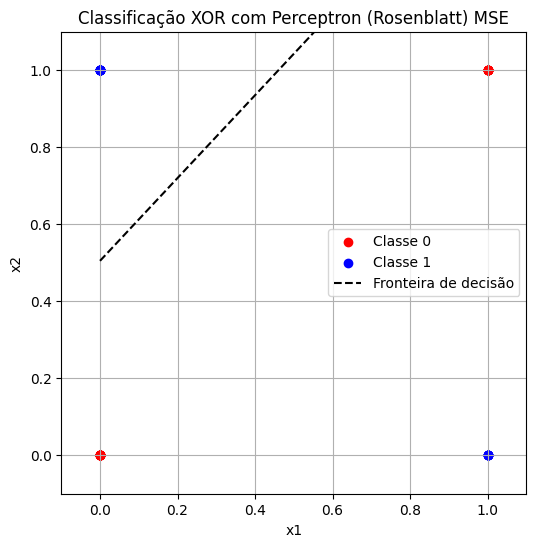

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6,6))

# pontos classificados
plt.scatter(x_test[d_test==0,0], x_test[d_test==0,1], color='red', label='Classe 0')
plt.scatter(x_test[d_test==1,0], x_test[d_test==1,1], color='blue', label='Classe 1')

# reta de separação
x_vals = np.array([0,1])
y_vals = -(W_final[1]/W_final[2])*x_vals - (W_final[0]/W_final[2])
plt.plot(x_vals, y_vals, 'k--', label='Fronteira de decisão')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Classificação XOR com Perceptron (Rosenblatt) MSE')
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)
plt.legend()
plt.grid(True)
plt.show()